In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("bioinformatics_visualization_practice_dataset.csv")

In [5]:
df

,Patient_ID,Age,Gender,Disease_Status,Gene_A_Expression,Gene_B_Expression,Gene_C_Expression,Blood_Pressure,Glucose,Mutation_A,Mutation_B,Mutation_C
0,P1001,60,Male,At Risk,5.55,5.97,4.94,148,115.0,Yes,Yes,Yes
1,P1002,50,Female,Healthy,4.43,5.54,3.40,137,102.0,No,Yes,No
2,P1003,36,Male,Disease,8.65,8.22,4.44,147,102.0,No,Yes,No
3,P1004,64,Female,Healthy,3.74,5.73,4.31,141,93.0,Yes,Yes,No
4,P1005,29,Male,Disease,8.17,7.84,3.23,110,111.0,Yes,No,No
5,P1006,42,Female,Healthy,5.42,2.76,3.44,128,89.0,Yes,Yes,No
6,P1007,60,Female,At Risk,4.35,5.09,3.87,130,113.0,Yes,No,No
7,P1008,40,Male,Healthy,4.89,8.25,5.17,135,NaN,No,No,No
8,P1009,44,Female,At Risk,7.16,6.57,5.55,130,90.0,No,Yes,No
9,P1010,32,Female,Healthy,6.11,3.32,5.13,122,96.0,No,No,No


In [6]:
df.head()

,Patient_ID,Age,Gender,Disease_Status,Gene_A_Expression,Gene_B_Expression,Gene_C_Expression,Blood_Pressure,Glucose,Mutation_A,Mutation_B,Mutation_C
0,P1001,60,Male,At Risk,5.55,5.97,4.94,148,115.0,Yes,Yes,Yes
1,P1002,50,Female,Healthy,4.43,5.54,3.40,137,102.0,No,Yes,No
2,P1003,36,Male,Disease,8.65,8.22,4.44,147,102.0,No,Yes,No
3,P1004,64,Female,Healthy,3.74,5.73,4.31,141,93.0,Yes,Yes,No
4,P1005,29,Male,Disease,8.17,7.84,3.23,110,111.0,Yes,No,No


In [14]:
df.shape
print("No of rows : ",df.shape[0])
print("No of columns : ",df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()


No of rows :  40
No of columns :  12

Column Names:
['Patient_ID', 'Age', 'Gender', 'Disease_Status', 'Gene_A_Expression', 'Gene_B_Expression', 'Gene_C_Expression', 'Blood_Pressure', 'Glucose', 'Mutation_A', 'Mutation_B', 'Mutation_C']

Data Types:
Patient_ID            object
Age                    int64
Gender                object
Disease_Status        object
Gene_A_Expression    float64
Gene_B_Expression    float64
Gene_C_Expression    float64
Blood_Pressure         int64
Glucose              float64
Mutation_A            object
Mutation_B            object
Mutation_C            object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         40 non-null     object 
 1   Age                40 non-null     int64  
 2   Gender             40 non-null     object 
 3   Disease_Status     

In [15]:
print("\nMissing Values in Each Column:")
missing_values = df.isnull().sum()
print(missing_values)


Missing Values in Each Column:
Patient_ID           0
Age                  0
Gender               0
Disease_Status       0
Gene_A_Expression    0
Gene_B_Expression    1
Gene_C_Expression    0
Blood_Pressure       0
Glucose              1
Mutation_A           0
Mutation_B           0
Mutation_C           0
dtype: int64


Disease    16
At Risk    12
Healthy    12
Name: Disease_Status, dtype: int64


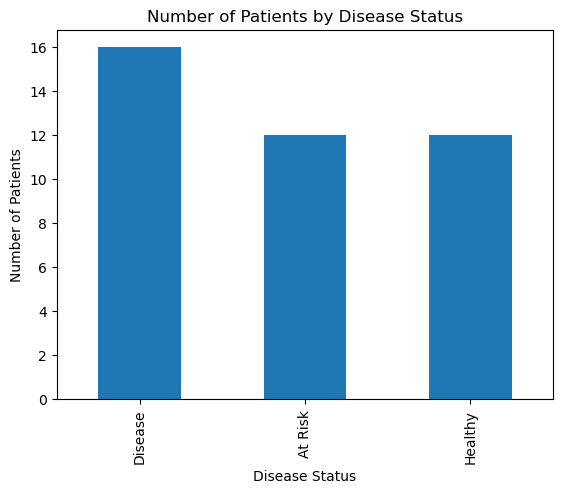

Highest group: Disease


In [29]:
# Q2 - BAR CHART: DISEASE STATUS

# a) Count Patients
print(df["Disease_Status"].value_counts())


# b) Create a Bar Chart 
count = df["Disease_Status"].value_counts()

count.plot(kind="bar")

plt.title("Number of Patients by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Number of Patients")
plt.show()


# c) Write one observation based on the bar chart. 
print("Highest group:", count.idxmax())

                Gene_A_Expression  Gene_B_Expression  Gene_C_Expression
Disease_Status                                                         
At Risk                  5.907500           6.415833           4.177500
Disease                  7.930000           7.478000           3.940000
Healthy                  4.271667           5.912500           5.045833


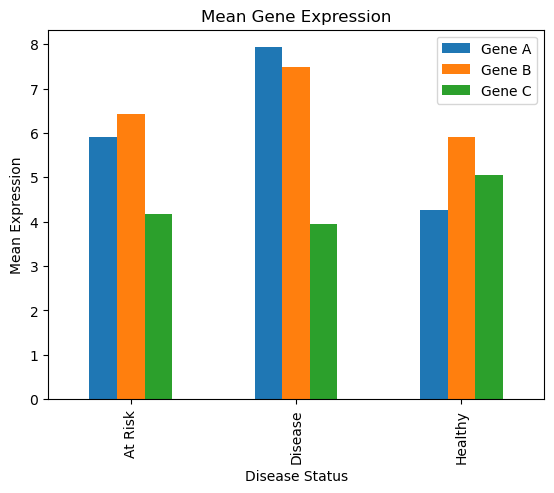

Group with highest overall expression: Disease


In [32]:
# Q3 - CLUSTERED BAR CHART

'''
# a) Calculate Mean Gene Expression 
Calculate the mean expression level of: 
• Gene A 
• Gene B 
• Gene C 
for each Disease_Status group. 
Present the calculated results in a suitable table. 
'''

mean_gene = df.groupby("Disease_Status")[
    ["Gene_A_Expression", "Gene_B_Expression", "Gene_C_Expression"]
].mean()

print(mean_gene)

# b) Create a Clustered Bar Chart
mean_gene.plot(kind="bar")

plt.title("Mean Gene Expression")
plt.xlabel("Disease Status")
plt.ylabel("Mean Expression")
plt.legend(["Gene A", "Gene B", "Gene C"])
plt.show()

# c) Which disease-status group generally shows higher gene expression?

print("Group with highest overall expression:",
      mean_gene.mean(axis=1).idxmax())


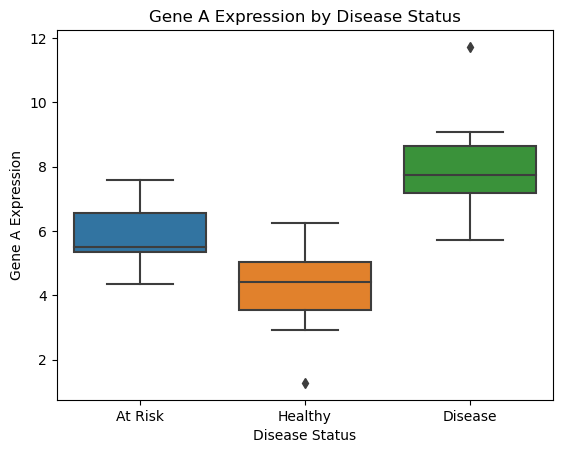

Median values:
Disease_Status
At Risk    5.495
Disease    7.755
Healthy    4.415
Name: Gene_A_Expression, dtype: float64
Highest median: Disease


In [34]:
# Q4 - BOX PLOT

'''
a) Create a Box Plot [6 Marks] 
Create a box plot showing Gene_A_Expression for each Disease_Status group. 
Include: 
• Appropriate title 
• X-axis label 
• Y-axis label 
• Clearly labelled disease-status groups 
'''
sns.boxplot(
    data=df,
    x="Disease_Status",
    y="Gene_A_Expression"
)

plt.title("Gene A Expression by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Gene A Expression")
plt.show()

'''
b) Compare Median Values [2 Marks] 
Examine the box plot and identify: 
Which disease-status group has the highest median Gene A expression? 
'''
median = df.groupby("Disease_Status")[
    "Gene_A_Expression"
].median()

print("Median values:")
print(median)

print("Highest median:", median.idxmax())



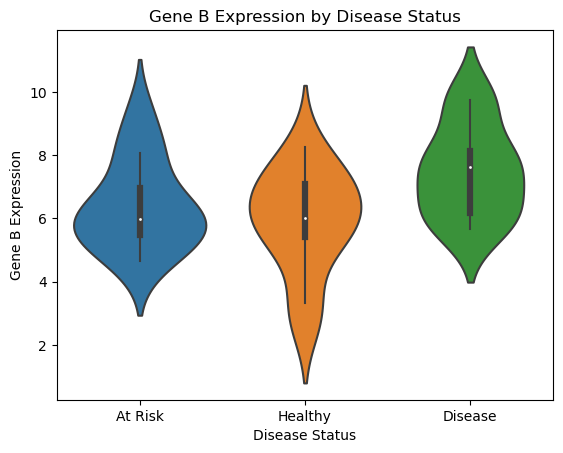

Mean Gene B:
Disease_Status
At Risk    6.415833
Disease    7.478000
Healthy    5.912500
Name: Gene_B_Expression, dtype: float64
Higher Gene B group: Disease
Violin width shows the density of data.


In [36]:
# Q5 – Violin Plot

'''
a) Create a Violin Plot [6 Marks] 
Create a violin plot showing Gene B expression for each disease-status group. 
Include: 
• Appropriate title 
• X-axis label 
• Y-axis label 
• Clearly labelled groups
'''

sns.violinplot(
    data=df,
    x="Disease_Status",
    y="Gene_B_Expression"
)

plt.title("Gene B Expression by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Gene B Expression")
plt.show()

'''
b) Compare Gene B Expression [2 Marks] 
Identify the disease-status group that generally shows higher Gene B expression.
'''

mean_b = df.groupby("Disease_Status")[
    "Gene_B_Expression"
].mean()

print("Mean Gene B:")
print(mean_b)

print("Higher Gene B group:", mean_b.idxmax())

print("Violin width shows the density of data.")


                        Age  Gene_A_Expression  Gene_B_Expression  \
Age                1.000000          -0.025905           0.202976   
Gene_A_Expression -0.025905           1.000000           0.227354   
Gene_B_Expression  0.202976           0.227354           1.000000   
Gene_C_Expression -0.128743          -0.341759          -0.235934   
Blood_Pressure     0.827266          -0.066273           0.171765   
Glucose            0.550290           0.294534           0.241752   

                   Gene_C_Expression  Blood_Pressure   Glucose  
Age                        -0.128743        0.827266  0.550290  
Gene_A_Expression          -0.341759       -0.066273  0.294534  
Gene_B_Expression          -0.235934        0.171765  0.241752  
Gene_C_Expression           1.000000       -0.036898 -0.290527  
Blood_Pressure             -0.036898        1.000000  0.470189  
Glucose                    -0.290527        0.470189  1.000000  


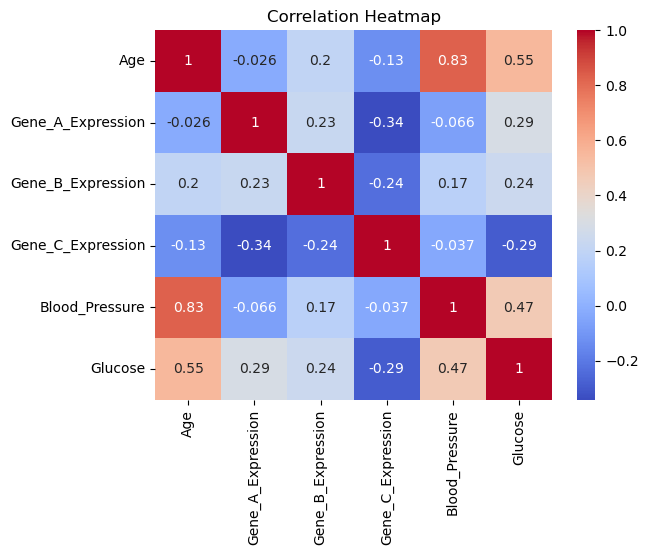

Strongest positive correlation:
('Age', 'Blood_Pressure')
0.8272658325720097


In [37]:
# Q6 – Heatmap

'''
a) Create a Correlation Matrix [4 Marks] 
Calculate the correlation matrix for the six selected variables. 
Display the correlation values.
'''

columns = [
    "Age",
    "Gene_A_Expression",
    "Gene_B_Expression",
    "Gene_C_Expression",
    "Blood_Pressure",
    "Glucose"
]

corr = df[columns].corr()

print(corr)


'''
b) Create a Heatmap [6 Marks] 
Create a correlation heatmap using the calculated correlation matrix. 
The heatmap should: 
• Display correlation values 
• Have appropriate labels 
• Have an appropriate title 
• Use a suitable colour scale 

'''
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


# c) Find strongest positive correlation
corr2 = corr.copy()

for i in range(len(corr2)):
    corr2.iloc[i, i] = 0

print("Strongest positive correlation:")

print(corr2.stack().idxmax())
print(corr2.stack().max())


Results:
                Gene  Disease Mean  Healthy Mean    Log2FC       P-value  \
0  Gene_A_Expression         7.930      4.271667  0.892522  5.648283e-07   
1  Gene_B_Expression         7.478      5.912500  0.338884  1.507578e-02   
2  Gene_C_Expression         3.940      5.045833 -0.356897  1.502358e-02   

   -log10(p)  
0   6.248084  
1   1.821720  
2   1.823226  


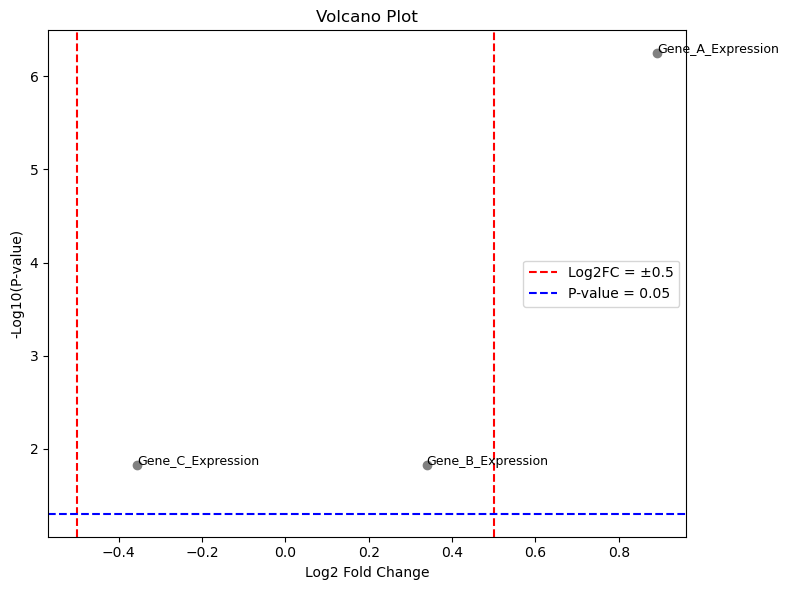


Significant genes:
Gene_A_Expression


In [43]:
# Q7 - VOLCANO PLOT

'''
a) Calculate Mean Expression [2 Marks] 
For each gene, calculate: 
1. Mean expression in the Disease group 
2. Mean expression in the Healthy group 

b) Calculate Log2 Fold Change [4 Marks] 
Calculate the log2 fold change for each gene using: 
log2 Fold Change = log2(Mean Disease Expression / Mean Healthy Expression) 
Calculate the value separately for: 
• Gene A 
• Gene B 
• Gene C 

c) Calculate Statistical Significance [3 Marks] 
Perform a two-sided independent t-test comparing the Disease and Healthy groups for each 
gene. 
Record the p-value for: 
• Gene A 
• Gene B 
• Gene C 

d) Create a Volcano Plot [4 Marks] 
Create a volcano plot using: 
• X-axis: Log2 Fold Change 
• Y-axis: −log10(p-value) 
Plot: 
• Gene A 
• Gene B 
• Gene C 
Label each gene on the plot. 
Use the following thresholds: 
• |log2FC| > 0.5 
• p < 0.05 

e) Interpretation [1 Mark] 
Identify which genes satisfy both of the following criteria: 
• |log2FC| > 0.5 
• p < 0.05 
Note: This is an illustrative teaching exercise for learning volcano plots and statistical 
visualization. It is not a formal biological differential-expression experiment.
'''

from scipy.stats import ttest_ind

# Genes to analyze
genes = [
    "Gene_A_Expression",
    "Gene_B_Expression",
    "Gene_C_Expression"
]


# Separate Disease and Healthy groups
disease = df[df["Disease_Status"] == "Disease"]
healthy = df[df["Disease_Status"] == "Healthy"]


# Store results
results = []


# Perform analysis for each gene
for gene in genes:

    # Remove missing values
    disease_values = disease[gene].dropna()
    healthy_values = healthy[gene].dropna()

    # Calculate means
    disease_mean = disease_values.mean()
    healthy_mean = healthy_values.mean()

    # Calculate Log2 Fold Change
    if healthy_mean > 0 and disease_mean > 0:
        log2fc = np.log2(disease_mean / healthy_mean)
    else:
        log2fc = np.nan

    # Independent two-sample t-test
    p = ttest_ind(
        disease_values,
        healthy_values,
        equal_var=False
    ).pvalue

    # Store results
    results.append([
        gene,
        disease_mean,
        healthy_mean,
        log2fc,
        p
    ])


# Create results DataFrame
result = pd.DataFrame(
    results,
    columns=[
        "Gene",
        "Disease Mean",
        "Healthy Mean",
        "Log2FC",
        "P-value"
    ]
)


# Calculate -log10(P-value)
result["-log10(p)"] = -np.log10(result["P-value"])


# Display results
print("Results:")
print(result)


# --------------------------------------------------
# Volcano Plot
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    result["Log2FC"],
    result["-log10(p)"],
    color="gray"
)


# Add gene labels
for i in range(len(result)):
    plt.text(
        result["Log2FC"].iloc[i],
        result["-log10(p)"].iloc[i],
        result["Gene"].iloc[i],
        fontsize=9
    )


# Log2FC threshold lines
plt.axvline(
    0.5,
    color="red",
    linestyle="--",
    label="Log2FC = ±0.5"
)

plt.axvline(
    -0.5,
    color="red",
    linestyle="--"
)


# P-value threshold line
plt.axhline(
    -np.log10(0.05),
    color="blue",
    linestyle="--",
    label="P-value = 0.05"
)


# Labels and title
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10(P-value)")
plt.title("Volcano Plot")


plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Significant Genes
# --------------------------------------------------

print("\nSignificant genes:")

significant_genes = result[
    (abs(result["Log2FC"]) > 0.5) &
    (result["P-value"] < 0.05)
]["Gene"]

print(significant_genes.to_string(index=False))



In [47]:
# Q8 – UpSet Plot: Mutation Intersections
'''
a) Prepare Mutation Data [3 Marks] 
Convert the mutation information into a suitable Boolean/set representation for creating an 
UpSet plot. 
For example: 
• Yes → True 
• No → False 
b) Create an UpSet Plot [5 Marks] 
Create an UpSet plot showing the intersections between: 
• Mutation A 
• Mutation B 
• Mutation C 
If the upsetplot library is not installed, install it before creating the plot. 
c) Identify the Most Common Combination [2 Marks] 
From the UpSet plot, identify the most common mutation combination/intersection. 
d) Interpretation [2 Marks] 
Explain why an UpSet plot can be more useful than a Venn diagram when analyzing multiple 
biological sets or mutation combinations.
'''
from scipy.stats import ttest_ind
from upsetplot import from_indicators

mutation = df[
    ["Mutation_A", "Mutation_B", "Mutation_C"]
].replace({
    "Yes": True,
    "No": False
})

print(mutation)

# Create UpSet plot
data = from_indicators(
    mutation.columns,
    mutation
)

UpSet(
    data,
    show_counts=True
).plot()

plt.show()

# Most common combination
print("Most common mutation combination:")

print(mutation.value_counts().head(1))


ModuleNotFoundError: No module named 'upsetplot'